# ダミーデータで学ぶ機械学習評価の落とし穴

生命健康科学分野における教育用最小実験を再現するノートブックです。

このノートブックでは次の3点を扱います。

1. 被験者リーク
2. ラベル・プロキシリーク
3. 補間と外挿の差

本ノートブックで扱うデータはすべて乱数から生成したダミーデータです。実在の被験者，患者，学生，動物に由来する情報は含みません。


## 0. Colab実行時の準備

GitHubからColabで開いた場合，以下のセルはリポジトリを `/content` にcloneします。ローカルで実行する場合はそのままスキップされます。

In [1]:
from pathlib import Path
import os, subprocess, sys

REPO_URL = "https://github.com/cSAS3/ml-evaluation-pitfalls-dummy-data.git"
REPO_DIR = Path("/content/ml-evaluation-pitfalls-dummy-data")

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=False)
    if REPO_DIR.exists():
        os.chdir(REPO_DIR)

print("Current working directory:", Path.cwd())

Current working directory: /home/oai


## 1. インポートと関数定義

In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, roc_auc_score, mean_squared_error

# Use repository root when running from local notebooks/ directory.
cwd = Path.cwd()
if cwd.name == "notebooks":
    ROOT = cwd.parent
else:
    ROOT = cwd

DATA_DIR = ROOT / "data"
FIG_DIR = ROOT / "figures"
RESULT_DIR = ROOT / "results"
for d in [DATA_DIR, FIG_DIR, RESULT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def make_subject_leakage_data(n_subjects=80, repeats=6, n_features=8, seed=0, sig=0.4, subj=1.4, noise=0.3):
    rng=np.random.default_rng(seed)
    subject_ids=np.repeat(np.arange(n_subjects), repeats)
    y_subject=rng.integers(0,2,size=n_subjects)
    y=np.repeat(y_subject, repeats)
    subject_signature=rng.normal(0, subj, size=(n_subjects,n_features))
    signal_vec=np.array([sig,sig*0.8,sig*0.6,sig*0.4]+[0]*(n_features-4))
    X=np.zeros((n_subjects*repeats,n_features))
    for s in range(n_subjects):
        idx=slice(s*repeats,(s+1)*repeats)
        X[idx]=subject_signature[s] + y_subject[s]*signal_vec + rng.normal(0,noise,size=(repeats,n_features))
    return X,y,subject_ids

def make_target_leakage_data(n=800, seed=0):
    rng=np.random.default_rng(seed)
    X=rng.normal(size=(n,6))
    logit=0.9*X[:,0]-0.7*X[:,1]+0.4*X[:,2]+0.3*rng.normal(size=n)
    p=1/(1+np.exp(-logit))
    y=rng.binomial(1,p,size=n)
    leak=y + 0.10*rng.normal(size=n)
    return X, np.column_stack([X, leak]), y

def make_extrapolation_data(seed=0, n_train=120, n_test_in=120, n_test_out=80):
    rng=np.random.default_rng(seed)
    x_train=np.sort(rng.uniform(0,8,size=n_train))
    y_train=2.2*x_train + 1.5 + rng.normal(0,0.8,size=n_train)
    x_in=np.sort(rng.uniform(0,8,size=n_test_in))
    y_in=2.2*x_in + 1.5 + rng.normal(0,0.8,size=n_test_in)
    x_out=np.sort(rng.uniform(8.5,12,size=n_test_out))
    y_out=2.2*x_out + 1.5 + rng.normal(0,0.8,size=n_test_out)
    return x_train[:,None], y_train, x_in[:,None], y_in, x_out[:,None], y_out

def savefig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches="tight")
    plt.close()


## 2. 20個の乱数種で評価を再現

In [3]:
# Subject leakage
subject_rows=[]
for seed in range(20):
    X,y,g=make_subject_leakage_data(seed=seed)
    cv1=StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    cv2=GroupKFold(n_splits=5)
    for condition, cv, groups in [('Sample-wise CV', cv1, None), ('Subject-wise CV', cv2, g)]:
        scores=[]
        iterator = cv.split(X,y) if groups is None else cv.split(X,y,groups)
        for tr,te in iterator:
            model=RandomForestClassifier(n_estimators=100, random_state=seed)
            model.fit(X[tr],y[tr])
            scores.append(accuracy_score(y[te], model.predict(X[te])))
        subject_rows.append({'seed':seed, 'condition':condition, 'score':np.mean(scores)})
df_subject=pd.DataFrame(subject_rows)

# Label/proxy leakage
target_rows=[]
for seed in range(20):
    X_sig, X_with, y = make_target_leakage_data(seed=seed)
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    for condition, X in [('Signal only', X_sig), ('Signal + leaked proxy', X_with)]:
        aucs=[]
        for tr,te in cv.split(X,y):
            model=LogisticRegression(max_iter=2000)
            model.fit(X[tr],y[tr])
            aucs.append(roc_auc_score(y[te], model.predict_proba(X[te])[:,1]))
        target_rows.append({'seed':seed, 'condition':condition, 'score':np.mean(aucs)})
df_target=pd.DataFrame(target_rows)

# Interpolation/extrapolation
extra_rows=[]
for seed in range(20):
    xtr,ytr,xin,yin,xout,yout=make_extrapolation_data(seed=seed)
    models={'Linear regression':LinearRegression().fit(xtr,ytr),
            'Random forest':RandomForestRegressor(n_estimators=150, random_state=seed).fit(xtr,ytr)}
    for model_name, model in models.items():
        pin=model.predict(xin)
        pout=model.predict(xout)
        extra_rows += [
            {'seed':seed, 'model':model_name, 'region':'Interpolation', 'rmse':float(np.sqrt(mean_squared_error(yin,pin)))},
            {'seed':seed, 'model':model_name, 'region':'Extrapolation', 'rmse':float(np.sqrt(mean_squared_error(yout,pout)))},
        ]
df_extra=pd.DataFrame(extra_rows)

summary_subject = df_subject.groupby('condition')['score'].agg(['mean','std'])
summary_target = df_target.groupby('condition')['score'].agg(['mean','std'])
summary_extra = df_extra.groupby(['model','region'])['rmse'].agg(['mean','std'])

display(summary_subject.round(3))
display(summary_target.round(3))
display(summary_extra.round(3))


,mean,std
condition,,
Sample-wise CV,0.946,0.013
Subject-wise CV,0.519,0.057


,mean,std
condition,,
Signal + leaked proxy,1.000,0.000
Signal only,0.769,0.014


mean    std
model             region                     
Linear regression Extrapolation  0.822  0.074
                  Interpolation  0.793  0.041
Random forest     Extrapolation  5.737  0.530
                  Interpolation  0.964  0.060

## 3. 図1：教育用最小実験のワークフロー

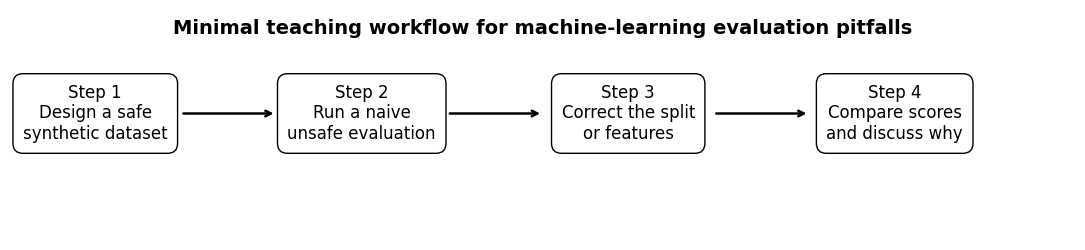

In [4]:
fig, ax = plt.subplots(figsize=(11, 2.6))
ax.axis('off')
steps = [
    ("Step 1", "Design a safe\nsynthetic dataset"),
    ("Step 2", "Run a naive\nunsafe evaluation"),
    ("Step 3", "Correct the split\nor features"),
    ("Step 4", "Compare scores\nand discuss why")
]
xs=[0.08,0.33,0.58,0.83]
for x,(title,body) in zip(xs, steps):
    ax.text(x,0.55,f"{title}\n{body}",ha='center',va='center',fontsize=12,
            bbox=dict(boxstyle='round,pad=0.6', fc='white', ec='black'))
for x1,x2 in zip(xs[:-1], xs[1:]):
    ax.annotate("", xy=(x2-0.08,0.55), xytext=(x1+0.08,0.55),
                arrowprops=dict(arrowstyle='->', lw=1.8))
ax.text(0.5, 0.92, "Minimal teaching workflow for machine-learning evaluation pitfalls",
        ha='center', va='center', fontsize=14, fontweight='bold')
savefig(FIG_DIR/'fig1_workflow.png')
display(fig)


## 4. 図2：被験者リーク

/tmp/ipykernel_2583/3235341886.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=conditions, widths=0.5, showfliers=False)


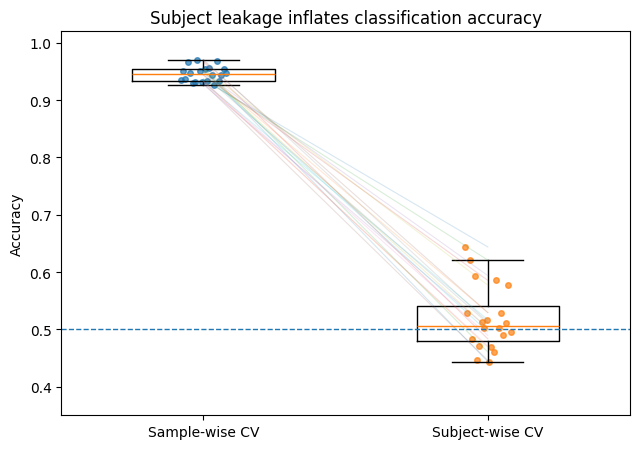

In [5]:
fig, ax = plt.subplots(figsize=(6.5,4.6))
conditions=['Sample-wise CV','Subject-wise CV']
data=[df_subject[df_subject['condition']==c]['score'].values for c in conditions]
ax.boxplot(data, labels=conditions, widths=0.5, showfliers=False)
for i,c in enumerate(conditions, start=1):
    vals=df_subject[df_subject['condition']==c].sort_values('seed')['score'].values
    jitter=np.linspace(-0.08,0.08,len(vals))
    ax.scatter(np.full_like(vals,i,dtype=float)+jitter, vals, s=16, alpha=0.7)
pairs = df_subject.pivot(index='seed', columns='condition', values='score').loc[:,conditions]
for _, row in pairs.iterrows():
    ax.plot([1,2], row.values, alpha=0.18, lw=0.8)
ax.axhline(0.5, ls='--', lw=1)
ax.set_ylabel('Accuracy')
ax.set_title('Subject leakage inflates classification accuracy')
ax.set_ylim(0.35,1.02)
savefig(FIG_DIR/'fig2_subject_leakage.png')
display(fig)


## 5. 図3：ラベル・プロキシリーク

/tmp/ipykernel_2583/879547352.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=conditions, widths=0.5, showfliers=False)


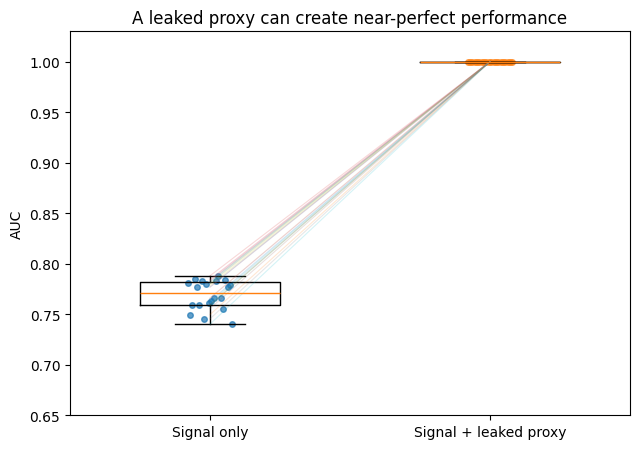

In [6]:
fig, ax = plt.subplots(figsize=(6.5,4.6))
conditions=['Signal only','Signal + leaked proxy']
data=[df_target[df_target['condition']==c]['score'].values for c in conditions]
ax.boxplot(data, labels=conditions, widths=0.5, showfliers=False)
for i,c in enumerate(conditions, start=1):
    vals=df_target[df_target['condition']==c].sort_values('seed')['score'].values
    jitter=np.linspace(-0.08,0.08,len(vals))
    ax.scatter(np.full_like(vals,i,dtype=float)+jitter, vals, s=16, alpha=0.7)
pairs = df_target.pivot(index='seed', columns='condition', values='score').loc[:,conditions]
for _, row in pairs.iterrows():
    ax.plot([1,2], row.values, alpha=0.18, lw=0.8)
ax.set_ylabel('AUC')
ax.set_title('A leaked proxy can create near-perfect performance')
ax.set_ylim(0.65,1.03)
savefig(FIG_DIR/'fig3_target_leakage.png')
display(fig)


## 6. 図4：補間と外挿

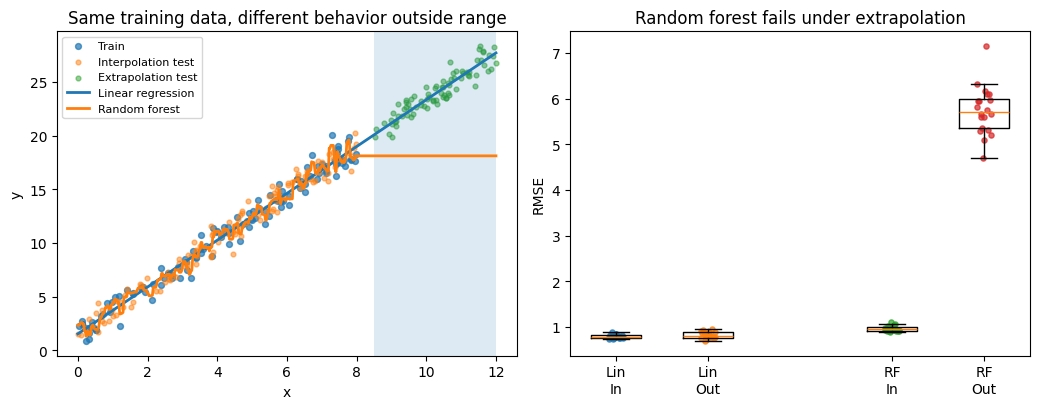

In [7]:
seed_for_curve=0
xtr,ytr,xin,yin,xout,yout=make_extrapolation_data(seed_for_curve)
lin=LinearRegression().fit(xtr,ytr)
rf=RandomForestRegressor(n_estimators=150, random_state=seed_for_curve).fit(xtr,ytr)
x_grid=np.linspace(0,12,500)[:,None]

fig, axes = plt.subplots(1,2, figsize=(10.5,4.2))
ax=axes[0]
ax.scatter(xtr[:,0], ytr, s=18, alpha=0.7, label='Train')
ax.scatter(xin[:,0], yin, s=12, alpha=0.5, label='Interpolation test')
ax.scatter(xout[:,0], yout, s=12, alpha=0.5, label='Extrapolation test')
ax.plot(x_grid[:,0], lin.predict(x_grid), lw=2, label='Linear regression')
ax.plot(x_grid[:,0], rf.predict(x_grid), lw=2, label='Random forest')
ax.axvspan(8.5, 12, alpha=0.15)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Same training data, different behavior outside range')
ax.legend(fontsize=8, loc='upper left')

ax=axes[1]
groups=[('Linear regression','Interpolation'), ('Linear regression','Extrapolation'),
        ('Random forest','Interpolation'), ('Random forest','Extrapolation')]
vals=[df_extra[(df_extra.model==m)&(df_extra.region==r)]['rmse'].values for m,r in groups]
positions=[1,2,4,5]
ax.boxplot(vals, positions=positions, widths=0.55, showfliers=False)
for pos,arr in zip(positions, vals):
    jitter=np.linspace(-0.08,0.08,len(arr))
    ax.scatter(np.full_like(arr,pos,dtype=float)+jitter, arr, s=14, alpha=0.7)
ax.set_xticks(positions)
ax.set_xticklabels(['Lin\nIn','Lin\nOut','RF\nIn','RF\nOut'])
ax.set_ylabel('RMSE')
ax.set_title('Random forest fails under extrapolation')

savefig(FIG_DIR/'fig4_extrapolation.png')
display(fig)


## 7. CSV出力

図と表の再現に使ったCSVを `data/` と `results/` に保存します。

In [8]:
# seed 0 datasets
X, y, groups = make_subject_leakage_data(seed=0)
df = pd.DataFrame(X, columns=[f"x{i+1}" for i in range(X.shape[1])])
df.insert(0, "label", y)
df.insert(0, "subject_id", groups)
df.to_csv(DATA_DIR / "subject_leakage_dummy_seed0.csv", index=False)

X_sig, X_with, y = make_target_leakage_data(seed=0)
df_sig = pd.DataFrame(X_with, columns=[f"signal_{i+1}" for i in range(6)] + ["leaked_proxy"])
df_sig.insert(0, "label", y)
df_sig.to_csv(DATA_DIR / "label_proxy_leakage_dummy_seed0.csv", index=False)

xtr, ytr, xin, yin, xout, yout = make_extrapolation_data(seed=0)
pd.DataFrame({"x": xtr[:,0], "y": ytr}).to_csv(DATA_DIR / "extrapolation_train_seed0.csv", index=False)
pd.DataFrame({"x": xin[:,0], "y": yin}).to_csv(DATA_DIR / "extrapolation_test_interpolation_seed0.csv", index=False)
pd.DataFrame({"x": xout[:,0], "y": yout}).to_csv(DATA_DIR / "extrapolation_test_extrapolation_seed0.csv", index=False)

df_subject.to_csv(RESULT_DIR / "subject_leakage_scores_20seeds.csv", index=False)
df_target.to_csv(RESULT_DIR / "label_proxy_leakage_scores_20seeds.csv", index=False)
df_extra.to_csv(RESULT_DIR / "extrapolation_scores_20seeds.csv", index=False)

summary_rows = []
for condition, row in summary_subject.iterrows():
    summary_rows.append({"experiment": "subject_leakage", "condition": condition, "metric": "accuracy", "mean": row["mean"], "std": row["std"]})
for condition, row in summary_target.iterrows():
    summary_rows.append({"experiment": "label_proxy_leakage", "condition": condition, "metric": "AUC", "mean": row["mean"], "std": row["std"]})
for (model, region), row in summary_extra.iterrows():
    summary_rows.append({"experiment": "extrapolation", "condition": f"{model} - {region}", "metric": "RMSE", "mean": row["mean"], "std": row["std"]})
pd.DataFrame(summary_rows).to_csv(RESULT_DIR / "summary_metrics_20seeds.csv", index=False)
with open(RESULT_DIR / "summary_metrics_20seeds.json", "w", encoding="utf-8") as f:
    json.dump(summary_rows, f, ensure_ascii=False, indent=2)

print("Saved outputs to:")
print("Data:", DATA_DIR.resolve())
print("Figures:", FIG_DIR.resolve())
print("Results:", RESULT_DIR.resolve())


Saved outputs to:
Data: /home/oai/data
Figures: /home/oai/figures
Results: /home/oai/results
